# 의료 이미지를 이용한 ViT Classification

### GPU check

In [1]:
from tensorflow.python.client import device_lib
device_lib.list_local_devices()

[name: "/device:CPU:0"
 device_type: "CPU"
 memory_limit: 268435456
 locality {
 }
 incarnation: 16203208469568406579,
 name: "/device:GPU:0"
 device_type: "GPU"
 memory_limit: 14727753280
 locality {
   bus_id: 1
   links {
   }
 }
 incarnation: 34043414066876292
 physical_device_desc: "device: 0, name: NVIDIA GeForce RTX 4080, pci bus id: 0000:01:00.0, compute capability: 8.9"]

In [2]:
import tensorflow as tf
tf.config.list_physical_devices('GPU')

[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]

In [3]:
gpus = tf.config.experimental.list_physical_devices('GPU')
for gpu in gpus:
    print('Name : ', gpu.name, 'Type : ', gpu.device_type)

Name :  /physical_device:GPU:0 Type :  GPU


In [4]:
!nvidia-smi -q


==============NVSMI LOG==============

Timestamp                                 : Mon Jan 30 11:46:19 2023
Driver Version                            : 527.56
CUDA Version                              : 12.0

Attached GPUs                             : 1
GPU 00000000:01:00.0
    Product Name                          : NVIDIA GeForce RTX 4080
    Product Brand                         : GeForce
    Product Architecture                  : Ada Lovelace
    Display Mode                          : Enabled
    Display Active                        : Enabled
    Persistence Mode                      : N/A
    MIG Mode
        Current                           : N/A
        Pending                           : N/A
    Accounting Mode                       : Disabled
    Accounting Mode Buffer Size           : 4000
    Driver Model
        Current                           : WDDM
        Pending                           : WDDM
    Serial Number                         : N/A
    GPU UUID        

# ViT

### 필요한 모듈 import

In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import tensorflow as tf

from tensorflow import keras
from tensorflow.keras import layers, Model, Sequential
from tensorflow.keras.layers import Layer, Dense, Input
from tensorflow.keras.layers import LayerNormalization
from tensorflow.keras.layers import Dropout, Add

from sklearn.utils import shuffle
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

In [6]:
tf.__version__

'2.4.1'

## 이미지 1개에 대한 ViT

In [7]:
import cv2

In [8]:
img = cv2.imread('./sample_image.jpg')

In [9]:
img.shape

(512, 512, 3)

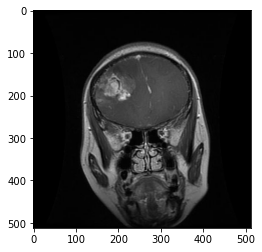

In [10]:
plt.imshow(img)

In [11]:
# 이미지 numpy.ndarray를 tensor로 변환하는 함수
# tf.constant : tensorflow에서 변수 선언에 사용

def changeToTensor(image):
    tensor_image = tf.constant(image)
    return tensor_image

In [12]:
tensor_image = changeToTensor(img)
tensor_image

<tf.Tensor: shape=(512, 512, 3), dtype=uint8, numpy=
array([[[0, 0, 0],
        [0, 0, 0],
        [0, 0, 0],
        ...,
        [0, 0, 0],
        [0, 0, 0],
        [0, 0, 0]],

       [[0, 0, 0],
        [0, 0, 0],
        [0, 0, 0],
        ...,
        [0, 0, 0],
        [0, 0, 0],
        [0, 0, 0]],

       [[0, 0, 0],
        [0, 0, 0],
        [0, 0, 0],
        ...,
        [0, 0, 0],
        [0, 0, 0],
        [0, 0, 0]],

       ...,

       [[0, 0, 0],
        [0, 0, 0],
        [0, 0, 0],
        ...,
        [0, 0, 0],
        [0, 0, 0],
        [0, 0, 0]],

       [[0, 0, 0],
        [0, 0, 0],
        [0, 0, 0],
        ...,
        [0, 0, 0],
        [0, 0, 0],
        [0, 0, 0]],

       [[0, 0, 0],
        [0, 0, 0],
        [0, 0, 0],
        ...,
        [0, 0, 0],
        [0, 0, 0],
        [0, 0, 0]]], dtype=uint8)>

In [13]:
tensor_image.shape

TensorShape([512, 512, 3])

### 추가 : ResizeImage()

In [14]:
# 이미지의 크기를 변경하는 함수
# batch_size는 임의로 1을 지정 -> patch 처리를 위함

def ResizeImage(image, image_size):
    batch_size = 1 # 임의로 지정
    resized_image = tf.image.resize(image, (image_size, image_size))
    resized_image = tf.reshape(resized_image, [batch_size, image_size, image_size, 3])
    return resized_image

In [15]:
# 이미지의 크기를 변경

resize_img_size_for_sample = 324
resized_img = ResizeImage(tensor_image, resize_img_size_for_sample) # resize_img_size = 324
resized_img.shape

TensorShape([1, 324, 324, 3])

In [18]:
# 이미지를 Patch 단위로 쪼개는 함수
# tf.image.extract_patches : input을 4D로 받아서 처리
# extract_patches 수행 후 reshape를 통해 batch_size, num_patches, patch_dimension으로 크기 변환
# patch를 나열하는 형태(sequence) 형태가 됨
patch_size = 18

def MakePatches(image, batch_size, patch_size):
    extract_patch = tf.image.extract_patches(
        images = image,
        sizes = [1, patch_size, patch_size, 1],
        strides = [1, patch_size, patch_size, 1],
        rates = [1, 1, 1, 1],
        padding = "VALID",
    )
    patch_dimension = extract_patch.shape[-1]
    patches = tf.reshape(extract_patch, [batch_size, -1, patch_dimension])
    return patches

In [19]:
# extract_patches 동작 원리

extract_patch = tf.image.extract_patches(
        images = resized_img,
        sizes = [1, patch_size, patch_size, 1],
        strides = [1, patch_size, patch_size, 1],
        rates = [1, 1, 1, 1],
        padding = "VALID",
    )
extract_patch

<tf.Tensor: shape=(1, 18, 18, 972), dtype=float32, numpy=
array([[[[0.       , 0.       , 0.       , ..., 0.       , 0.       ,
          0.       ],
         [0.       , 0.       , 0.       , ..., 2.       , 2.       ,
          2.       ],
         [0.       , 0.       , 0.       , ..., 2.       , 2.       ,
          2.       ],
         ...,
         [0.       , 0.       , 0.       , ..., 2.       , 2.       ,
          2.       ],
         [0.       , 0.       , 0.       , ..., 0.       , 0.       ,
          0.       ],
         [0.       , 0.       , 0.       , ..., 0.       , 0.       ,
          0.       ]],

        [[0.       , 0.       , 0.       , ..., 0.       , 0.       ,
          0.       ],
         [0.       , 0.       , 0.       , ..., 3.       , 3.       ,
          3.       ],
         [2.       , 2.       , 2.       , ..., 3.       , 3.       ,
          3.       ],
         ...,
         [2.       , 2.       , 2.       , ..., 2.6705937, 2.6705937,
          2.67

In [20]:
batch_size_for_sample = 1
patch_size_for_sample = 18
patch_img = MakePatches(resized_img, batch_size_for_sample, patch_size_for_sample)
patch_img

<tf.Tensor: shape=(1, 324, 972), dtype=float32, numpy=
array([[[0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 2., 2., 2.],
        [0., 0., 0., ..., 2., 2., 2.],
        ...,
        [2., 2., 2., ..., 0., 0., 0.],
        [2., 2., 2., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.]]], dtype=float32)>

==> patch의 개수 18 * 18 = 324개

In [21]:
# patch sequence Linear Projection을 통과함
# projection_dimension : 972

projection_dimension = patch_img.shape[-1] # 972
projection_image = Dense(projection_dimension)(patch_img)
projection_image

<tf.Tensor: shape=(1, 324, 972), dtype=float32, numpy=
array([[[-0.267523  ,  0.26467204,  0.12093046, ...,  0.14663889,
         -0.20456381,  0.04757525],
        [ 0.63016635,  2.9846594 , -2.8865213 , ...,  1.0636641 ,
          2.5581203 , -1.9486308 ],
        [ 0.19830394,  3.705643  , -2.0689836 , ..., -0.8959072 ,
          0.5191134 , -0.6453389 ],
        ...,
        [-0.24819383,  3.5532825 , -1.5400202 , ..., -0.6592141 ,
          1.00053   , -1.3567653 ],
        [-0.29452008,  2.53476   , -1.6949097 , ..., -0.4172703 ,
         -0.2904924 , -0.99065447],
        [-0.04883957,  0.16538095, -0.05187225, ...,  0.07673264,
         -0.04946733, -0.01285934]]], dtype=float32)>

In [22]:
# class token 생성 class
# layer의 add_weight를 이용하여 랜덤하게 생성함

class ClassToken(tf.keras.Model):
    def __init__(self, dimension, batch_size):
        self.dimension = dimension
        self.batch_size = batch_size 
        super(ClassToken, self).__init__()
        
    def build(self, dimension):
        self.class_token = self.add_weight(
            shape = [1, 1, self.dimension],
            initializer = tf.keras.initializers.RandomNormal(), dtype = tf.float32
        )
        
    def call(self, dimension):
        class_token = tf.broadcast_to(
            self.class_token, [self.batch_size, 1, self.dimension]
        )
        return class_token

In [23]:
cls_token = ClassToken(dimension = patch_img.shape[-1], batch_size = batch_size_for_sample)(patch_img)
cls_token

<tf.Tensor: shape=(1, 1, 972), dtype=float32, numpy=
array([[[ 0.0172655 ,  0.0304229 ,  0.07047462, -0.04243454,
         -0.03598445, -0.08536915, -0.15052496, -0.0176074 ,
          0.0075871 ,  0.03626974, -0.02159512, -0.0014387 ,
          0.01952399, -0.00144056,  0.06667928, -0.00758936,
          0.10749774, -0.03560749,  0.0180639 , -0.08924239,
          0.0546085 ,  0.01065873, -0.05257365,  0.03246665,
         -0.07582869, -0.06839163, -0.07959972, -0.04960797,
         -0.01517596, -0.04160083, -0.04523049,  0.07801416,
          0.02806205,  0.03348427, -0.08694925, -0.00710394,
         -0.00398587,  0.07167239,  0.0541325 , -0.02190439,
         -0.0263901 , -0.01148392, -0.03183415,  0.06361263,
          0.04089412, -0.00882298, -0.00527166, -0.04615873,
          0.05886583, -0.03162306,  0.04478405, -0.0821246 ,
          0.02657283, -0.0424946 ,  0.04999525, -0.01037287,
         -0.00827797, -0.09702569,  0.15469311, -0.02894957,
          0.00760653, -0.0715764

In [24]:
# class token과 linear projection을 열 방향으로 결합

concat_img = tf.concat([cls_token, projection_image], axis = 1) # 열 단위로 접합
concat_img

<tf.Tensor: shape=(1, 325, 972), dtype=float32, numpy=
array([[[ 0.0172655 ,  0.0304229 ,  0.07047462, ..., -0.01568185,
         -0.0628474 , -0.01663265],
        [-0.267523  ,  0.26467204,  0.12093046, ...,  0.14663889,
         -0.20456381,  0.04757525],
        [ 0.63016635,  2.9846594 , -2.8865213 , ...,  1.0636641 ,
          2.5581203 , -1.9486308 ],
        ...,
        [-0.24819383,  3.5532825 , -1.5400202 , ..., -0.6592141 ,
          1.00053   , -1.3567653 ],
        [-0.29452008,  2.53476   , -1.6949097 , ..., -0.4172703 ,
         -0.2904924 , -0.99065447],
        [-0.04883957,  0.16538095, -0.05187225, ...,  0.07673264,
         -0.04946733, -0.01285934]]], dtype=float32)>

In [25]:
# position embedding
# patch sequence 길이만큼 position을 생성한 후 Embedding 수행
# Embedding 정수 인코딩 단어(여기선 position)를 밀집 벡터로 만드는 역할

num_patches_for_sample = (resize_img_size_for_sample // patch_size_for_sample) ** 2 # 324
position = tf.range(start = 0, limit = concat_img.shape[1], delta = 1)

position_embedding = layers.Embedding(input_dim = num_patches_for_sample + 1, output_dim = projection_dimension)(position)
print(position)
print(position_embedding)

tf.Tensor(
[  0   1   2   3   4   5   6   7   8   9  10  11  12  13  14  15  16  17
  18  19  20  21  22  23  24  25  26  27  28  29  30  31  32  33  34  35
  36  37  38  39  40  41  42  43  44  45  46  47  48  49  50  51  52  53
  54  55  56  57  58  59  60  61  62  63  64  65  66  67  68  69  70  71
  72  73  74  75  76  77  78  79  80  81  82  83  84  85  86  87  88  89
  90  91  92  93  94  95  96  97  98  99 100 101 102 103 104 105 106 107
 108 109 110 111 112 113 114 115 116 117 118 119 120 121 122 123 124 125
 126 127 128 129 130 131 132 133 134 135 136 137 138 139 140 141 142 143
 144 145 146 147 148 149 150 151 152 153 154 155 156 157 158 159 160 161
 162 163 164 165 166 167 168 169 170 171 172 173 174 175 176 177 178 179
 180 181 182 183 184 185 186 187 188 189 190 191 192 193 194 195 196 197
 198 199 200 201 202 203 204 205 206 207 208 209 210 211 212 213 214 215
 216 217 218 219 220 221 222 223 224 225 226 227 228 229 230 231 232 233
 234 235 236 237 238 239 240 241 242 243

In [26]:
concat_img[0][0][0]

<tf.Tensor: shape=(), dtype=float32, numpy=0.017265497>

In [27]:
position_embedding[0][0]

<tf.Tensor: shape=(), dtype=float32, numpy=0.01207627>

In [28]:
0.014326686 + -0.008979011

0.005347675

In [29]:
# concat 결과값과 position embedding을 덧셈연산으로 결합 

encoder_input = concat_img + position_embedding
encoder_input

<tf.Tensor: shape=(1, 325, 972), dtype=float32, numpy=
array([[[ 0.02934177, -0.00732405,  0.11678907, ..., -0.01909217,
         -0.03317165,  0.02700809],
        [-0.24395268,  0.31113735,  0.08930811, ...,  0.1477946 ,
         -0.20025265,  0.00385881],
        [ 0.62805855,  2.974818  , -2.9123437 , ...,  1.0415088 ,
          2.5733454 , -1.910443  ],
        ...,
        [-0.24651323,  3.5383475 , -1.5302992 , ..., -0.6241457 ,
          1.0258462 , -1.3881016 ],
        [-0.29098204,  2.5089447 , -1.6745245 , ..., -0.45928288,
         -0.25113037, -1.0301037 ],
        [-0.09305783,  0.11700392, -0.02640038, ...,  0.0439596 ,
         -0.08005603, -0.03899119]]], dtype=float32)>

In [30]:
# patch를 head 개수만큼 나누는 함수

def split_heads(x, batch_size, num_heads):
    depth = x.shape[-1] // num_heads
    
    x = tf.reshape(x, (batch_size, -1, num_heads, depth))
    return tf.transpose(x, perm = [0, 2, 1, 3])

In [31]:
# head 마다의 Scaled Dot Product Attention 수행

def ScaledDotProductAttention(Q, K, V):
    qk = tf.matmul(Q, K, transpose_b = True)
    dim_k = tf.cast(tf.shape(K)[-1], tf.float32)
    
    logits = qk / tf.math.sqrt(dim_k)
    qk_softmax = tf.nn.softmax(logits, axis = -1)
    attention_score = tf.matmul(qk_softmax, V)
    
    return attention_score

In [32]:
# 병렬처리
# MultiHeadAttention 구현

class MultiHeadAttention(tf.keras.Model):
    def __init__(self, dimension, num_heads):
        super(MultiHeadAttention, self).__init__()
        self.dimension = dimension
        self.num_heads = num_heads
        self.depth = dimension // num_heads

        self.WQ = Dense(dimension)
        self.WK = Dense(dimension)
        self.WV = Dense(dimension)
        self.WO = Dense(dimension)

    def call(self, inputs):
        output = None
        batch_size = tf.shape(inputs)[0]
        query = self.WQ(inputs)
        key = self.WK(inputs)
        value = self.WV(inputs)

        Q = split_heads(query, batch_size, self.num_heads)
        K = split_heads(key, batch_size, self.num_heads)
        V = split_heads(value, batch_size, self.num_heads)

        attention_score = ScaledDotProductAttention(Q,K,V)

        scaled_attention = tf.transpose(attention_score, perm = [0, 2, 1, 3])
        concat_attention = tf.reshape(scaled_attention, (batch_size, -1, self.dimension))
        output = self.WO(concat_attention)

        return output

In [33]:
# dimension = 972, num_heads = 18

m = MultiHeadAttention(972, 18)(encoder_input)
m

<tf.Tensor: shape=(1, 325, 972), dtype=float32, numpy=
array([[[ -81.56273  ,   -9.69004  ,   -1.3964354, ...,  -86.57669  ,
         -186.00684  ,  -23.160526 ],
        [-107.98412  ,    4.6734276,  -55.49677  , ..., -122.28273  ,
          -66.80133  ,   28.016033 ],
        [ -47.003395 , -138.85464  ,    1.001916 , ...,  -90.03252  ,
         -107.03539  ,   56.24406  ],
        ...,
        [ -13.950342 ,  -33.317657 ,  -35.912773 , ...,  -54.043095 ,
          -98.86847  ,   14.167527 ],
        [ -14.454061 ,   18.523975 ,  -48.991844 , ..., -163.39508  ,
         -161.65596  ,   70.371605 ],
        [ -50.72147  ,  -29.545052 ,  -17.905466 , ...,   62.043526 ,
         -114.28401  ,   71.83183  ]]], dtype=float32)>

In [34]:
# Transformer의 MLP
# hidden_units = [dimension, dimension] [972, 972]
# dimension을 유지

def MLP(x, hidden_units, dropout_rate):
    for units in hidden_units:
        x = layers.Dense(units, activation = tf.nn.gelu)(x)
        x = layers.Dropout(dropout_rate)(x)
        return x

In [35]:
# Transformer Encoder 구현
# LayerNorm -> Attention -> + Residual
# LayerNorm -> MLP -> + Residual

def TransformerEncoder(encoder_input, dimension, num_heads):
    x = LayerNormalization(epsilon = 1e-6)(encoder_input)
    attention_score = MultiHeadAttention(dimension, num_heads)(x)
    x_res = Add()([attention_score, encoder_input])
    x2 = LayerNormalization(epsilon = 1e-6)(x_res)
    x3 = MLP(x2, [dimension, dimension], dropout_rate = 0.2)
    encoder_output = Add()([x3, x_res])
    return encoder_output

In [36]:
num_heads_for_sample = 18
encoder_output = TransformerEncoder(encoder_input, dimension = encoder_input.shape[-1], num_heads = num_heads_for_sample)
encoder_output

<tf.Tensor: shape=(1, 325, 972), dtype=float32, numpy=
array([[[ 1.0070252 , -0.61238265,  2.8164897 , ..., -0.09211135,
          1.2052019 ,  0.7589798 ],
        [ 0.34440288,  0.06085929,  1.7672334 , ..., -0.06215502,
          0.48040712,  0.8121151 ],
        [ 1.1990005 ,  2.052944  , -1.6860188 , ...,  1.5292993 ,
          2.1328738 , -1.4225705 ],
        ...,
        [ 0.5628344 ,  3.292255  , -0.33763373, ..., -0.54450065,
          0.55502695, -0.6797073 ],
        [ 0.22841075,  2.2679543 , -0.25811654, ..., -0.23451257,
         -0.6860033 , -0.3356102 ],
        [ 0.58985186, -0.8328526 ,  2.676661  , ..., -0.18470919,
          0.258039  ,  1.762614  ]]], dtype=float32)>

In [37]:
# representation = class token
# 325 patch sequence 중에 첫번째 값

representation = encoder_output[:,0,:]
print(representation.shape)
representation

(1, 972)


<tf.Tensor: shape=(1, 972), dtype=float32, numpy=
array([[ 1.00702524e+00, -6.12382650e-01,  2.81648970e+00,
         1.61013603e+00, -9.62443113e-01,  1.23711061e+00,
        -5.31957805e-01,  1.86392784e+00,  3.25188458e-01,
         4.18387800e-01,  9.83878493e-01,  2.71689028e-01,
        -3.46197426e-01,  3.10431391e-01,  7.42664218e-01,
         2.59476542e-01,  1.82393223e-01, -3.65228131e-02,
        -8.68286192e-01, -8.92794967e-01,  9.14113045e-01,
        -1.77827269e-01, -4.45461512e-01,  6.26854748e-02,
         6.69110775e-01, -1.13666654e-01, -5.66549838e-01,
        -2.69293785e-01,  5.07827997e-01, -3.23422551e-01,
        -1.98514521e-01,  2.86913991e-01,  7.61241972e-01,
         1.02346206e+00,  3.91827285e-01,  7.14140415e-01,
         5.02008855e-01,  6.38670802e-01, -6.27328098e-01,
         2.37692642e+00, -2.02393562e-01,  1.07300627e+00,
        -1.90570998e+00,  1.97128192e-01,  2.12631607e+00,
        -1.22959876e+00,  7.08373666e-01, -3.04042786e-01,
      

In [38]:
# Classifier (MLP를 했었어야 했는데 놓치고 지나간 부분...!!)

cls = Dense(4)(representation)
cls

<tf.Tensor: shape=(1, 4), dtype=float32, numpy=array([[-1.0413556, -1.657661 ,  1.1660914,  2.203199 ]], dtype=float32)>

# 전체 이미지에 대한 학습

### 필요한 모듈

In [39]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import tensorflow as tf

from tensorflow import keras
from tensorflow.keras import layers, Model, Sequential
from tensorflow.keras.layers import Layer, Dense, Input
from tensorflow.keras.layers import LayerNormalization
from tensorflow.keras.layers import Dropout, Add

from sklearn.utils import shuffle
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

In [40]:
import cv2

In [41]:
import os

### 이미지 로드

In [42]:
# 이미지 로드

# 이미지 폴더 기본 경로
base_path = './brain_mri'

# Train, Test folder 경로
train_folder = os.path.join(base_path, 'Training')
test_folder = os.path.join(base_path, 'Testing')

# labels : 라벨 이름 리스트
labels = []
for folder in os.listdir(train_folder):
    labels.append(folder)
    
labels

['glioma', 'meningioma', 'notumor', 'pituitary']

In [43]:
# Train, Test sub folder = Class image folder
# Train, Test 각 Class folder 경로명을 dictionary에 저장

train_sub_dict = {}
test_sub_dict = {}
for i in labels:
    train_sub_dict[i] = os.path.join(base_path, 'Training', i)
    test_sub_dict[i] = os.path.join(base_path, 'Testing', i)
    
train_sub_dict, test_sub_dict

({'glioma': './brain_mri\\Training\\glioma',
  'meningioma': './brain_mri\\Training\\meningioma',
  'notumor': './brain_mri\\Training\\notumor',
  'pituitary': './brain_mri\\Training\\pituitary'},
 {'glioma': './brain_mri\\Testing\\glioma',
  'meningioma': './brain_mri\\Testing\\meningioma',
  'notumor': './brain_mri\\Testing\\notumor',
  'pituitary': './brain_mri\\Testing\\pituitary'})

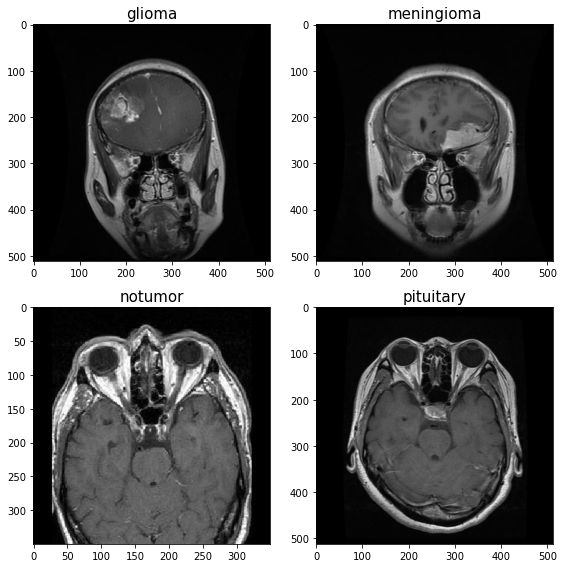

In [44]:
# Class 별 이미지 1개씩 출력

plt.figure(figsize = (8,8))
for i,label in enumerate(labels):
    img_name = os.listdir(train_sub_dict[label])
    
    plt.subplot(2,2,i+1)
    img = cv2.imread(os.path.join(train_sub_dict[label], img_name[0]))
    plt.imshow(img)
    plt.title(label, fontsize = 15)
    
plt.tight_layout()
plt.show()

## ViT - 구현 def 사용

### 이미지 로드

In [45]:
# 하나의 numpy array로 합치기 위해서 이미지의 크기가 동일해야함

# 통일할 이미지 크기
img_height = 512
img_width = 512

In [46]:
# Train image 전체를 하나의 변수에 할당
# 이미지를 불러오고 size를 수정한 후 list에 append
# Train Label 생성
X_train_d = []
y_train_d = []

for i in labels:
    for j in os.listdir(train_sub_dict[i]):
        img_path = os.path.join(train_sub_dict[i], j)
        img = cv2.imread(img_path)
        img = cv2.resize(img, (img_height, img_width))
        X_train_d.append(img)
        y_train_d.append(i)

# Test image, Label
X_test_d = []
y_test_d = []

for i in labels:
    for j in os.listdir(test_sub_dict[i]):
        img_path = os.path.join(test_sub_dict[i], j)
        img = cv2.imread(img_path)
        img = cv2.resize(img, (img_height, img_width))
        X_test_d.append(img)
        y_test_d.append(i)

# 하나의 numpy array로 변환
X_train_np = np.array(X_train_d)
X_test_np = np.array(X_test_d)

# Train label 숫자화
# 이미지 폴더명과 앞서 생성한 labels list의 index를 이용하여 숫자 라벨 생성
y_train_num = []
y_test_num = []

for m in y_train_d:
    y_train_num.append(labels.index(m))
for n in y_test_d:
    y_test_num.append(labels.index(n))
    
y_train_num = np.array(y_train_num)
y_test_num = np.array(y_test_num)

In [47]:
X_train_np.shape, X_test_np.shape, y_train_num.shape, y_test_num.shape

((5712, 512, 512, 3), (1311, 512, 512, 3), (5712,), (1311,))

### 변수 정의

In [48]:
batch_size = 100
image_size = 324
patch_size = 18
num_patches = (image_size // patch_size) ** 2
num_heads = 18
dimension = 18*18*3
hidden_units = dimension
dropout_rate = 0.2
num_class = 4
epoch = 100

### numpy array를 tensor로 변환 - 사용X

In [49]:
# 이미지 numpy.ndarray를 tensor로 변환하는 함수
# tf.constant : tensorflow에서 변수 선언에 사용

def changeToTensor(image):
    tensor_image = tf.constant(image)
    return tensor_image

### 이미지의 크기를 줄여줌

In [50]:
# 이미지 크기를 변경하는 함수

def ResizeImage(image, image_size):
    resized_image = tf.image.resize(image, (image_size, image_size))
    resized_image = tf.reshape(resized_image, [batch_size, image_size, image_size, 3])
    return resized_image

### 이미지를 patch 단위로 자르기

In [51]:
# 이미지를 Patch 단위로 쪼개는 함수
# tf.image.extract_patches : input을 4D로 받아서 처리
# extract_patches 수행 후 reshape를 통해 batch_size, num_patches, patch_dimension으로 크기 변환
# patch를 나열하는 형태(sequence) 형태가 됨

def MakePatches(image, patch_size):
    extract_patch = tf.image.extract_patches(
        images = image,
        sizes = [1, patch_size, patch_size, 1],
        strides = [1, patch_size, patch_size, 1],
        rates = [1, 1, 1, 1],
        padding = "VALID",
    )
    patch_dimension = extract_patch.shape[-1]
    batch_size = image.shape[0]
    patches = tf.reshape(extract_patch, [batch_size, -1, patch_dimension])
    return patches

### Class Token Class

In [52]:
# class token 생성 class
# layer의 add_weight를 이용하여 랜덤하게 생성함

class ClassToken(tf.keras.Model):
    def __init__(self, dimension, batch_size):
        self.dimension = dimension
        self.batch_size = batch_size
        super(ClassToken, self).__init__()
        
    def build(self, dimension):
        self.class_token = self.add_weight(
            shape = [1, 1, self.dimension],
            initializer = tf.keras.initializers.RandomNormal(), dtype = tf.float32
        )
        
    def call(self, dimension):
        class_token = tf.broadcast_to(
            self.class_token, [self.batch_size, 1, self.dimension]
        )
        return class_token

### MultiHeadAttention의 head를 나누는 함수

In [53]:
# patch를 head 개수만큼 나누는 함수

def split_heads(x, batch_size, num_heads):
    depth = x.shape[-1] // num_heads
    
    x = tf.reshape(x, (batch_size, -1, num_heads, depth))
    return tf.transpose(x, perm = [0, 2, 1, 3])

### SelfAttention 함수

In [54]:
# head 마다의 Scaled Dot Product Attention 수행

def ScaledDotProductAttention(Q, K, V):
    qk = tf.matmul(Q, K, transpose_b = True)
    dim_k = tf.cast(tf.shape(K)[-1], tf.float32)
    
    logits = qk / tf.math.sqrt(dim_k)
    qk_softmax = tf.nn.softmax(logits, axis = -1)
    attention_score = tf.matmul(qk_softmax, V)
    
    return attention_score

### MultiHeadAttention Class

In [55]:
# 병렬처리
# MultiHeadAttention 구현

class MultiHeadAttention_d(tf.keras.Model):
    def __init__(self, dimension, num_heads):
        super(MultiHeadAttention_d, self).__init__()
        self.dimension = dimension
        self.num_heads = num_heads
        self.depth = dimension // num_heads

        self.WQ = Dense(dimension)
        self.WK = Dense(dimension)
        self.WV = Dense(dimension)
        self.WO = Dense(dimension)

    def call(self, inputs):
        output = None
        batch_size = tf.shape(inputs)[0]
        query = self.WQ(inputs)
        key = self.WK(inputs)
        value = self.WV(inputs)
        
        Q = split_heads(query, batch_size, self.num_heads)
        K = split_heads(key, batch_size, self.num_heads)
        V = split_heads(value, batch_size, self.num_heads)
        
        attention_score = ScaledDotProductAttention(Q,K,V)

        scaled_attention = tf.transpose(attention_score, perm = [0, 2, 1, 3])
        concat_attention = tf.reshape(scaled_attention, (batch_size, -1, self.dimension))
        output = self.WO(concat_attention)

        return output

In [56]:
# Transformer의 MLP
# hidden_units = [dimension, dimension] [972, 972]
# dimension을 유지

def MLP_d(x, hidden_units, dropout_rate):
    for units in hidden_units:
        x = layers.Dense(units, activation = tf.nn.gelu)(x)
        x = layers.Dropout(dropout_rate)(x)
    return x

In [57]:
# Transformer Encoder 구현
# LayerNorm -> Attention -> + Residual
# LayerNorm -> MLP -> + Residual

def TransformerEncoder(encoder_input, dimension, num_heads):
    x = LayerNormalization(epsilon = 1e-6)(encoder_input)
    attention_score = MultiHeadAttention_d(dimension, num_heads)(x)
    x_res = Add()([attention_score, encoder_input])
    x2 = LayerNormalization(epsilon = 1e-6)(x_res)
    x3 = MLP_d(x2, [dimension, dimension], dropout_rate = 0.2)
    encoder_output = Add()([x3, x_res])
    return encoder_output

In [58]:
# 전체 VisionTransformer 모델 설계

def VisionTransformer():
    inputs = layers.Input(shape = (None, None,3,))
    
    batch_size = 100 # reshape error 문제로 batch_size 지정
    resized_image = ResizeImage(inputs, image_size)
    patches = MakePatches(resized_image, patch_size)
    
    # patch Linear Projection 통과
    projection_dimension = patches.shape[-1]
    projection_image = Dense(projection_dimension)(patches)
    
    # Class token 생성
    cls_token = ClassToken(dimension = patches.shape[-1], batch_size = patches.shape[0])(patches)
    
    # Class token과 projection output을 열 방향 결합
    concat_img = tf.concat([cls_token, projection_image], axis = 1)
    
    # position Embedding
    position_limit = concat_img.shape[1] # 325
    position = tf.range(start = 0, limit = position_limit, delta = 1) # sequence 길이의 position 생성
    # Embedding 수행
    position_embedding = layers.Embedding(input_dim = num_patches + 1, output_dim = projection_dimension)(position)

    # Embedding 결과를 concat한 image squence와 결합
    encoder_input = concat_img + position_embedding
    
    encoder_data = encoder_input
    
    # Transformer Encoder 3회 수행
    # dimension = 972로 유지
    for i in range(3):
        encoder_data = TransformerEncoder(encoder_data, dimension = 972, num_heads = 18)
        
    encoder_output = encoder_data
    
    # LayerNorm을 통과
    z = LayerNormalization(epsilon = 1e-6)(encoder_output)
    
    # class token만 추출
    representation = z[:,0,:]
    
    # MLP를 통과 : layer는 486, 216으로 설정
    o = MLP_d(representation, hidden_units = [486, 216], dropout_rate = 0.2)
    
    # Classifier
    out = Dense(num_class, activation = 'softmax')(o) # num_class = 4
   
    model = Model(inputs = inputs, outputs = out)
    return model

In [150]:
vit = VisionTransformer()

In [151]:
vit.summary()

Model: "model_1"
__________________________________________________________________________________________________
Layer (type)                    Output Shape         Param #     Connected to                     
input_2 (InputLayer)            [(None, None, None,  0                                            
__________________________________________________________________________________________________
tf.image.resize_1 (TFOpLambda)  (None, 324, 324, 3)  0           input_2[0][0]                    
__________________________________________________________________________________________________
tf.reshape_2 (TFOpLambda)       (100, 324, 324, 3)   0           tf.image.resize_1[0][0]          
__________________________________________________________________________________________________
tf.image.extract_patches_1 (TFO (100, 18, 18, 972)   0           tf.reshape_2[0][0]               
____________________________________________________________________________________________

### Train, Test 데이터 생성

In [152]:
# batch_size로 인해 데이터를 100단위의 숫자만큼 샘플링

from sklearn.utils import shuffle
X, y = shuffle(X_train_np, y_train_num)
X_t, y_t = shuffle(X_test_np, y_test_num)

X = X[:5700] # 수정
y = y[:5700]

X_t = X_t[:1300]
y_t = y_t[:1300]

In [153]:
X.shape, y.shape, X_t.shape, y_t.shape

((5700, 512, 512, 3), (5700,), (1300, 512, 512, 3), (1300,))

### 모델 컴파일, 학습

In [154]:
vit.compile(
    optimizer = tf.optimizers.Adam(learning_rate = 0.001),
    loss = tf.keras.losses.SparseCategoricalCrossentropy(),
    metrics = [
        tf.keras.metrics.SparseCategoricalAccuracy(name = 'accuracy'),
    ],
)

history = vit.fit(
    x = X,
    y = y,
    batch_size = 100,
    epochs = 100,
    validation_data = (X_t, y_t),
    shuffle = True
)

Epoch 1/100
57/57 [==============================] - 25s 407ms/step - loss: 1.9317 - accuracy: 0.2928 - val_loss: 1.2467 - val_accuracy: 0.4400
Epoch 2/100
57/57 [==============================] - 23s 399ms/step - loss: 1.0591 - accuracy: 0.5623 - val_loss: 1.0455 - val_accuracy: 0.6069
Epoch 3/100
57/57 [==============================] - 23s 399ms/step - loss: 0.8741 - accuracy: 0.6520 - val_loss: 0.8532 - val_accuracy: 0.6300
Epoch 4/100
57/57 [==============================] - 23s 398ms/step - loss: 0.7873 - accuracy: 0.6883 - val_loss: 0.8461 - val_accuracy: 0.6585
Epoch 5/100
57/57 [==============================] - 23s 400ms/step - loss: 0.7885 - accuracy: 0.6791 - val_loss: 0.9611 - val_accuracy: 0.6508
Epoch 6/100
57/57 [==============================] - 23s 398ms/step - loss: 0.6746 - accuracy: 0.7389 - val_loss: 0.7043 - val_accuracy: 0.7200
Epoch 7/100
57/57 [==============================] - 23s 399ms/step - loss: 0.6677 - accuracy: 0.7287 - val_loss: 0.7248 - val_accuracy:

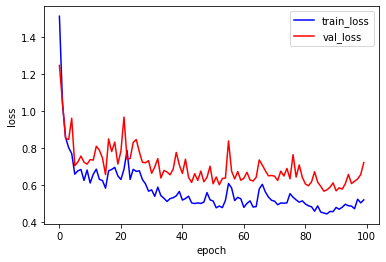

In [155]:
fig, axis = plt.subplots()
axis.plot(history.history['loss'], 'b', label = 'train_loss')
axis.plot(history.history['val_loss'], 'r', label = 'val_loss')
axis.set_xlabel('epoch')
axis.set_ylabel('loss')

plt.legend()
plt.show()

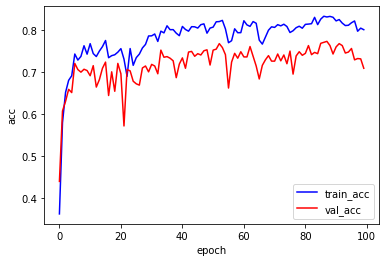

In [156]:
fig, axis = plt.subplots()

axis.plot(history.history['accuracy'], 'b', label = 'train_acc')
axis.plot(history.history['val_accuracy'], 'r', label = 'val_acc')
axis.set_xlabel('epoch')
axis.set_ylabel('acc')

plt.legend()
plt.show()

### 모델 평가

In [158]:
_, accuracy = vit.evaluate(X_t, y_t, batch_size = 100)
print('Test Acc : ', accuracy)

13/13 [==============================] - 2s 127ms/step - loss: 0.7216 - accuracy: 0.7085
Test Acc :  0.7084615230560303


### 모델 예측

In [175]:
from sklearn.utils import shuffle
sample_X, sample_y = shuffle(X_test_np, y_test_num)
sample_X = sample_X[:1000]
sample_y = sample_y[:1000]

In [176]:
sample_X.shape

(1000, 512, 512, 3)

In [177]:
y_pred = vit.predict(sample_X, batch_size = 100)

In [178]:
y_pred[0].argmax(), sample_y[0]

(2, 1)

In [179]:
y_pred_l = []
for i in range(len(y_pred)):
    y_pred_l.append(y_pred[i].argmax())
    
y_pred_l = np.array(y_pred_l)
y_pred_l[0]

2

In [180]:
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

In [181]:
print(classification_report(sample_y, y_pred_l, target_names = labels))

              precision    recall  f1-score   support

      glioma       0.73      0.82      0.77       243
  meningioma       0.49      0.44      0.46       233
     notumor       0.75      0.94      0.83       301
   pituitary       0.91      0.56      0.69       223

    accuracy                           0.71      1000
   macro avg       0.72      0.69      0.69      1000
weighted avg       0.72      0.71      0.70      1000



In [182]:
cm = confusion_matrix(sample_y, y_pred_l)

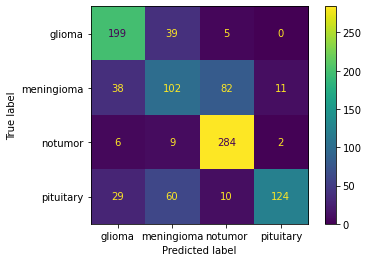

In [183]:
ConfusionMatrix = ConfusionMatrixDisplay(confusion_matrix = cm, display_labels = labels)
ConfusionMatrix.plot()

## ViT class로 구현

### 이미지 resize하지 않기 때문에 image 로드 시 324, 324

In [116]:
img_height = 324
img_width = 324

In [117]:
X_train = []
y_train = []

for i in labels:
    for j in os.listdir(train_sub_dict[i]):
        img_path = os.path.join(train_sub_dict[i], j)
        img = cv2.imread(img_path)
        img = cv2.resize(img, (img_height, img_width))
        X_train.append(img)
        y_train.append(i)   

In [118]:
X_test = []
y_test = []

for i in labels:
    for j in os.listdir(test_sub_dict[i]):
        img_path = os.path.join(test_sub_dict[i], j)
        img = cv2.imread(img_path)
        img = cv2.resize(img, (img_height, img_width))
        X_test.append(img)
        y_test.append(i)  

In [119]:
X_train_numpy = np.array(X_train)
X_test_numpy = np.array(X_test)

y_train_numeric = []
y_test_numeric = []

for i in y_train:
    y_train_numeric.append(labels.index(i))
for j in y_test:
    y_test_numeric.append(labels.index(j))
    
y_train_numeric = np.array(y_train_numeric)
y_test_numeric = np.array(y_test_numeric)

In [120]:
X_train_numpy.shape, X_test_numpy.shape, y_train_numeric.shape, y_test_numeric.shape

((5712, 324, 324, 3), (1311, 324, 324, 3), (5712,), (1311,))

### 변수 정의

In [121]:
batch_size = 100
image_size = 324
patch_size = 18
num_patches = (image_size // patch_size) ** 2
num_heads = 18
dimension = 18*18*3
hidden_units = dimension
dropout_rate = 0.2
num_class = 4
epoch = 50

### 모델 Class

In [122]:
class MultiHeadAttention(tf.keras.Model):
    def __init__(self, dimension, num_heads):
        super(MultiHeadAttention, self).__init__()
        self.dimension = dimension
        self.num_heads = num_heads
        self.depth = dimension // num_heads

        self.WQ = Dense(dimension)
        self.WK = Dense(dimension)
        self.WV = Dense(dimension)
        self.WO = Dense(dimension)

    def call(self, inputs):
        output = None
        batch_size = tf.shape(inputs)[0]
        query = self.WQ(inputs)
        key = self.WK(inputs)
        value = self.WV(inputs)
        
        def split_heads(x, batch_size, num_heads):
            x = tf.reshape(x, (batch_size, -1, self.num_heads, self.depth))
            return tf.transpose(x, perm = [0, 2, 1, 3])
        
        Q = split_heads(query, batch_size, self.num_heads)
        K = split_heads(key, batch_size, self.num_heads)
        V = split_heads(value, batch_size, self.num_heads)
        
        def ScaledDotProductAttention(Q, K, V):
            qk = tf.matmul(Q, K, transpose_b = True)
            dim_k = tf.cast(tf.shape(K)[-1], tf.float32)

            logits = qk / tf.math.sqrt(dim_k)
            qk_softmax = tf.nn.softmax(logits, axis = -1)
            attention_score = tf.matmul(qk_softmax, V)

            return attention_score
        
        attention_score = ScaledDotProductAttention(Q,K,V)

        scaled_attention = tf.transpose(attention_score, perm = [0, 2, 1, 3])
        concat_attention = tf.reshape(scaled_attention, (batch_size, -1, self.dimension))
        output = self.WO(concat_attention)

        return output

In [123]:
class MLP(layers.Layer):
    def __init__(self, hidden_units, dropout_rate):
        super(MLP, self).__init__()
        
        self.hidden_units = hidden_units
        self.dropout_rate = dropout_rate
        
        self.HiddenDense = Dense(hidden_units, activation = tf.nn.gelu)
        self.dropout = layers.Dropout(self.dropout_rate)
        self.OutDense = Dense(hidden_units, activation = tf.nn.gelu)
        
    def call(self, inputs):
        output = None
        
        x = self.HiddenDense(inputs)
        x = self.dropout(x)
        x = self.OutDense(x)
        output = self.dropout(x)
        
        return output

In [124]:
class ClassToken(tf.keras.Model):
    def __init__(self, dimension, batch_size):
        self.dimension = dimension
        self.batch_size = batch_size
        super(ClassToken, self).__init__()
        
    def build(self, dimension):
        self.class_token = self.add_weight(
            shape = [1, 1, self.dimension],
            initializer = tf.keras.initializers.RandomNormal(), dtype = tf.float32
        )
        
    def call(self, dimension):
        class_token = tf.broadcast_to(
            self.class_token, [self.batch_size, 1, self.dimension]
        )
        return class_token

In [125]:
class Transformer(layers.Layer):
    def __init__(self, dimension, num_heads, hidden_units, dropout_rate):
        super(Transformer, self).__init__()
        
        self.dimension = dimension
        self.num_heads = num_heads
        self.hidden_units = hidden_units
        self.dropout_rate = dropout_rate
        
        self.LayerNorm = LayerNormalization(epsilon = 1e-6)
        self.MultiHeadAttention = MultiHeadAttention(self.dimension, self.num_heads)
        self.MLP = MLP(self.hidden_units, self.dropout_rate)
        
    def call(self, inputs):
        x = self.LayerNorm(inputs)
        attention_score = self.MultiHeadAttention(x)
        x_res = layers.Add()([attention_score, inputs])
        x2 = self.LayerNorm(x_res)
        x3 = self.MLP(x2)
        encoder_output = layers.Add()([x3, x_res])
        return encoder_output

In [126]:
class ViT(tf.keras.Model):
    def __init__(
            self, image_size, batch_size, patch_size, num_class, num_heads, dimension,
            hidden_units, dropout_rate):
        super(ViT, self).__init__()
        
        num_patches = (image_size // patch_size) ** 2
        
        self.batch_size = batch_size
        self.patch_size = patch_size
        self.num_class = num_class
        self.num_heads = num_heads
        self.num_patches = num_patches
        self.dimension = dimension # 972
        self.hidden_units = hidden_units
        self.dropout_rate = dropout_rate
        
        self.LayerNorm = LayerNormalization(epsilon = 1e-6)
        self.Projection = Dense(self.dimension)
        self.ClassToken = ClassToken(self.dimension, self.batch_size)
        self.PositionEmbedding = layers.Embedding(input_dim = self.num_patches + 1, output_dim = self.dimension)
        self.Transformer = Transformer(self.dimension, self.num_heads, self.hidden_units, self.dropout_rate)
        self.Classifier = Dense(self.num_class, activation = 'softmax')
        
    def call(self, inputs):
        output = None
        batch_size = tf.shape(inputs)[0]
        
        patches = tf.image.extract_patches(
            images = inputs,
            sizes = [1, self.patch_size, self.patch_size, 1],
            strides = [1, self.patch_size, self.patch_size, 1],
            rates = [1,1,1,1],
            padding="VALID",
        )
        
        patch_dimension = patches.shape[-1]
        patches = tf.reshape(patches, [self.batch_size, patches.shape[1]*patches.shape[2], patch_dimension])
        
        projection = self.Projection(patches)
        
        cls_token = self.ClassToken(patches)
        
        concat = tf.concat([cls_token, projection], axis = 1)
        
        position = tf.range(start = 0, limit = concat.shape[1], delta = 1)
        position_embedding = self.PositionEmbedding(position)
        
        encoder_input = concat + position_embedding
        encoder_data = encoder_input
        
        for i in range(3):
            encoder_data = self.Transformer(encoder_data)
            
        encoder_output = encoder_data
        z = self.LayerNorm(encoder_output)
        representation = z[:,0,:]
        output = self.Classifier(representation)
        return output

In [127]:
vit2 = ViT(image_size, batch_size, patch_size, num_class, num_heads, dimension, hidden_units, dropout_rate)

In [128]:
vit2.compile(
    optimizer = tf.optimizers.Adam(learning_rate = 0.001),
    loss = tf.keras.losses.SparseCategoricalCrossentropy(),
    metrics = [
        tf.keras.metrics.SparseCategoricalAccuracy(name = 'accuracy'),
    ],
)

### Train, Test 데이터 생성

In [129]:
Train_data, Train_label = shuffle(X_train_numpy, y_train_numeric)
Test_data, Test_label = shuffle(X_test_numpy, y_test_numeric)

Train_data = Train_data[:5700]
Train_label = Train_label[:5700]

Test_data = Test_data[:1300]
Test_label = Test_label[:1300]

In [130]:
Train_data.shape, Train_label.shape, Test_data.shape, Test_label.shape

((5700, 324, 324, 3), (5700,), (1300, 324, 324, 3), (1300,))

### 모델 학습

In [131]:
history = vit2.fit(
    x = Train_data,
    y = Train_label,
    batch_size = batch_size,
    epochs = epoch,
    validation_data = (Test_data, Test_label),
    shuffle = True
)

Epoch 1/50
57/57 [==============================] - 25s 417ms/step - loss: 4.8506 - accuracy: 0.2851 - val_loss: 1.2353 - val_accuracy: 0.4762
Epoch 2/50
57/57 [==============================] - 23s 411ms/step - loss: 1.0976 - accuracy: 0.5354 - val_loss: 1.0843 - val_accuracy: 0.5462
Epoch 3/50
57/57 [==============================] - 23s 412ms/step - loss: 0.9713 - accuracy: 0.6165 - val_loss: 0.9604 - val_accuracy: 0.6131
Epoch 4/50
57/57 [==============================] - 23s 412ms/step - loss: 0.8028 - accuracy: 0.6812 - val_loss: 0.9423 - val_accuracy: 0.6369
Epoch 5/50
57/57 [==============================] - 24s 414ms/step - loss: 0.7420 - accuracy: 0.7096 - val_loss: 0.8403 - val_accuracy: 0.6485
Epoch 6/50
57/57 [==============================] - 23s 411ms/step - loss: 0.6549 - accuracy: 0.7378 - val_loss: 0.8669 - val_accuracy: 0.6723
Epoch 7/50
57/57 [==============================] - 23s 413ms/step - loss: 0.6312 - accuracy: 0.7566 - val_loss: 0.7622 - val_accuracy: 0.7023

In [132]:
vit2.summary()

Model: "vi_t_1"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
layer_normalization_11 (Laye multiple                  1944      
_________________________________________________________________
dense_41 (Dense)             multiple                  945756    
_________________________________________________________________
class_token_3 (ClassToken)   multiple                  972       
_________________________________________________________________
embedding_3 (Embedding)      multiple                  315900    
_________________________________________________________________
transformer_1 (Transformer)  multiple                  5676480   
_________________________________________________________________
dense_48 (Dense)             multiple                  3892      
Total params: 6,944,944
Trainable params: 6,944,944
Non-trainable params: 0
__________________________________________________

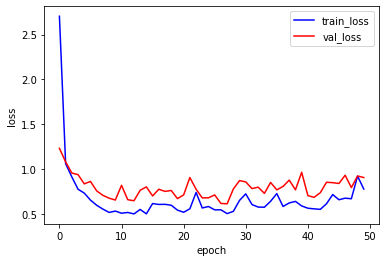

In [133]:
fig, axis = plt.subplots()
axis.plot(history.history['loss'], 'b', label = 'train_loss')
axis.plot(history.history['val_loss'], 'r', label = 'val_loss')
axis.set_xlabel('epoch')
axis.set_ylabel('loss')

plt.legend()
plt.show()

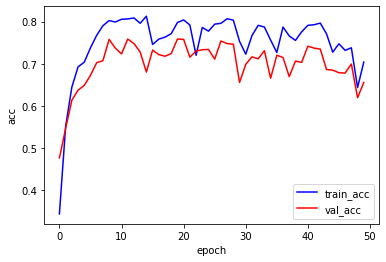

In [134]:
fig, axis = plt.subplots()

axis.plot(history.history['accuracy'], 'b', label = 'train_acc')
axis.plot(history.history['val_accuracy'], 'r', label = 'val_acc')
axis.set_xlabel('epoch')
axis.set_ylabel('acc')

plt.legend()
plt.show()

### 모델 평가

In [135]:
_, accuracy = vit2.evaluate(Test_data, Test_label, batch_size = 100)
print('Test Acc : ', accuracy)

13/13 [==============================] - 2s 142ms/step - loss: 0.9105 - accuracy: 0.6554
Test Acc :  0.6553846001625061


### 모델 예측

In [136]:
y_pred2 = vit2.predict(Test_data, batch_size = 100)

In [137]:
y_pred2_l = []

for i in range(len(y_pred2)):
    y_pred2_l.append(y_pred2[i].argmax())
    
y_pred2_l = np.array(y_pred2_l)
y_pred2_l[0]

3

### Confusion Matrix

In [138]:
print(classification_report(Test_label, y_pred2_l, target_names = labels))

              precision    recall  f1-score   support

      glioma       0.71      0.77      0.74       297
  meningioma       0.49      0.42      0.45       303
     notumor       0.69      0.92      0.78       402
   pituitary       0.71      0.43      0.53       298

    accuracy                           0.66      1300
   macro avg       0.65      0.63      0.63      1300
weighted avg       0.65      0.66      0.64      1300



In [139]:
cm2 = confusion_matrix(Test_label, y_pred2_l)

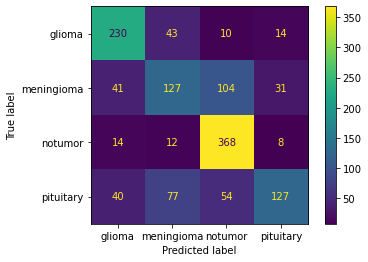

In [140]:
ConfusionMatrix2 = ConfusionMatrixDisplay(confusion_matrix = cm2, display_labels = labels)
ConfusionMatrix2.plot()